### Bitcoin Market Sentiment vs Trader Performance Analysis

## Project Objective

The objective of this project is to analyze the relationship between Bitcoin market sentiment and trader performance using historical trading data from Hyperliquid and the Fear & Greed Index dataset.

The analysis aims to identify patterns in trader behavior, leverage usage, profitability, and risk-taking tendencies under different market sentiment conditions such as Fear, Greed, Extreme Fear, and Extreme Greed.

## Datasets Used

### 1. Historical Trader Dataset
This dataset contains detailed trader activity including:
- Coin traded
- Execution price
- Trade size
- Position details
- Profit and loss
- Leverage-related behavior
- Trade timestamps

### 2. Fear & Greed Index Dataset
This dataset contains daily market sentiment information including:
- Fear & Greed score
- Sentiment classification
- Date and timestamp

## Importing Library and Inspecting Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.shape

(211224, 16)

In [6]:
sentiment.shape

(2644, 4)

In [7]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [8]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [9]:
sentiment["classification"].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [10]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [11]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [12]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [13]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [14]:
trades.duplicated().sum()

np.int64(0)

In [15]:
sentiment.duplicated().sum()

np.int64(0)

In [16]:
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


- The dataset contains more than 211,000 trading records, providing a large sample for behavioral analysis.
- Trade sizes and position values vary significantly, indicating the presence of both small retail trades and large high-volume trades.
- Closed PnL values contain both profits and losses, with some extreme outliers representing highly profitable or highly losing trades.
- The median Closed PnL is 0, suggesting that many records may correspond to position openings, partial executions, or trades without realized profit/loss.
- Start Position values include both positive and negative values, indicating the existence of both long and short positions.
- Execution prices vary widely because the dataset contains multiple cryptocurrencies with different price ranges.
- Fee values include negative entries, which may represent maker rebates provided by the exchange for adding liquidity.

#### Note on Data Distribution
Key numeric columns including Closed PnL, Size USD, and Fee are highly right-skewed 
(skewness > 20) with extreme kurtosis, indicating the strong presence of outlier 
trades and whale-level activity.

As a result:
- Median is used alongside mean throughout this analysis to give a robust picture
- Visualizations use percentile-based capping where needed to avoid distortion

In [17]:
trades["Closed PnL"].value_counts().head(20)

Closed PnL
 0.000000     106816
 0.146908         80
-1.566400         71
 9.903600         67
 88.459120        62
 0.059631         51
 0.066620         50
 0.095175         50
 1.149000         46
 1.955000         45
 0.008400         42
 3.766400         41
 89.710900        41
 5.028000         40
 0.063308         40
 0.900000         39
-88.438400        39
-2.988002         39
 3.153300         38
 0.069631         37
Name: count, dtype: int64


THis shows that a large number of records contain a value of 0. This suggests that the dataset includes execution-level trading activity such as:
- Position openings
- Position scaling
- Partial executions
- Trades without realized profit or loss
  
The dataset also contains both positive and negative PnL values, confirming the presence of profitable as well as loss-making trades.
Additionally, repeated small profit/loss values may indicate high-frequency or algorithmic trading behavior. The presence of extreme positive and negative values suggests that some traders were involved in highly leveraged or high-risk trading activities.

In [18]:
trades["Coin"].nunique()

246

In [19]:
trades["Coin"].unique()[:20]

array(['@107', 'AAVE', 'DYDX', 'AIXBT', 'GMX', 'EIGEN', 'HYPE', 'SOL',
       'SUI', 'DOGE', 'ETH', 'kPEPE', 'TRUMP', 'ONDO', 'ENA', 'LINK',
       'XRP', 'S', 'BNB', 'BERA'], dtype=object)

In [20]:
trades["Coin"].value_counts().head(20)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
TRUMP         1920
XRP           1774
kPEPE         1730
kBONK         1647
FTT           1560
ONDO          1463
@142          1309
PAXG          1265
ZRO           1239
PURR          1198
Name: count, dtype: int64

In [21]:
trades["Timestamp IST"].min()

'01-01-2024 01:23'

In [22]:
trades["Timestamp IST"].max()

'31-12-2024 23:33'

In [23]:
sentiment["date"].min()

'2018-02-01'

In [24]:
sentiment["date"].max()

'2025-05-02'

In [25]:
trades[["Size USD", "Closed PnL", "Fee"]].describe(percentiles=[0.95, 0.99])

,Size USD,Closed PnL,Fee
count,2.112240e+05,211224.000000,211224.000000
mean,5.639451e+03,48.749001,1.163967
std,3.657514e+04,919.164828,6.758854
min,0.000000e+00,-117990.104100,-1.175712
50%,5.970450e+02,0.000000,0.089578
95%,2.002301e+04,165.788894,4.499446
99%,8.888725e+04,1023.315314,20.999698
max,3.921431e+06,135329.090100,837.471593


1. The dataset contains highly variable trade sizes, profit/loss values, and fees, indicating diverse trading behavior.
2. The average trade size is much higher than the median trade size, suggesting the presence of a few extremely large trades.
3. The maximum trade size exceeds \$3.9 million, indicating whale-level or institutional trading activity.
4. The Closed PnL column contains both large profits and losses, showing highly volatile and leveraged trading behavior.
5. The median Closed PnL value is 0, suggesting that many rows may represent position openings or partial executions.
6. The dataset contains significant outliers and skewed distributions, which are common in financial trading data.

In [26]:
numeric_cols = trades.select_dtypes(include="number")
numeric_cols.corr()["Closed PnL"].sort_values(ascending=False)

Closed PnL         1.000000
Size USD           0.123589
Fee                0.084020
Size Tokens        0.005068
Start Position     0.004066
Trade ID           0.003466
Execution Price   -0.006505
Order ID          -0.007250
Timestamp         -0.009745
Name: Closed PnL, dtype: float64

Size USD shows the strongest positive correlation with Closed PnL, suggesting that larger trade sizes are associated with larger profits or losses.

In [27]:
trades["Side"].unique()

array(['BUY', 'SELL'], dtype=object)

In [28]:
trades["Direction"].unique()

array(['Buy', 'Sell', 'Open Long', 'Close Long', 'Spot Dust Conversion',
       'Open Short', 'Close Short', 'Long > Short', 'Short > Long',
       'Auto-Deleveraging', 'Liquidated Isolated Short', 'Settlement'],
      dtype=object)

In [29]:
trades.groupby("Coin")["Closed PnL"].mean().sort_values(ascending=False).head(10)

Coin
@109       270.704207
AVAX       239.095613
ENA        219.524751
@85        200.804091
EIGEN      197.063189
PEOPLE     180.323003
DOGE       178.623676
SOL        153.358519
MOODENG    151.096714
ZRO        148.327509
Name: Closed PnL, dtype: float64

### Data Preprocessing

In [30]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], format="mixed", dayfirst=True)

In [31]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

In [32]:
trades["Timestamp IST"].dtype

dtype('<M8[ns]')

In [33]:
sentiment["date"].dtype

dtype('<M8[ns]')

In [34]:
trades["date"] = trades["Timestamp IST"].dt.date

In [35]:
sentiment["date"] = sentiment["date"].dt.date

In [36]:
trades["date"].head()

0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: date, dtype: object

In [37]:
sentiment["date"].head()

0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object

In [38]:
missing_dates = set(trades["date"]) - set(sentiment["date"])

len(missing_dates)

1

In [39]:
missing_dates

{datetime.date(2024, 10, 26)}

In [40]:
merged_df = pd.merge(
    trades,
    sentiment,
    on="date",
    how="left"
)

In [41]:
merged_df.shape

(211224, 20)

In [42]:
merged_df[["date", "classification"]].head()

,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [43]:
merged_df["classification"].isnull().sum()

np.int64(6)

In [44]:
merged_df = merged_df.dropna(subset=["classification"])

In [45]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [46]:
merged_df["classification"].isnull().sum()

np.int64(0)

In [85]:
daily_account = merged_df.groupby(["Account", "date", "classification"]).agg(
    total_pnl=("Closed PnL", "sum"),
    trade_count=("Closed PnL", "count"),
    avg_trade_size=("Size USD", "mean"),
    win_rate=("Closed PnL", lambda x: (x > 0).mean() * 100)
).reset_index()

print("Daily account-level metrics shape:", daily_account.shape)
daily_account.head(10)

Daily account-level metrics shape: (2340, 7)


,Account,date,classification,total_pnl,trade_count,avg_trade_size,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.000000,177,5089.718249,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.000000,68,7976.664412,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.000000,40,23734.500000,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.000000,12,28186.666667,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.100000,27,17248.148148,44.444444
5,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,Extreme Greed,-132271.000000,82,16058.536341,0.000000
6,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-30,Extreme Greed,0.000000,23,48561.685652,0.000000
7,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-12-06,Greed,-175611.000056,33,36736.362424,0.000000
8,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-19,Extreme Greed,71393.964098,465,11410.954022,4.946237
9,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-20,Extreme Greed,40218.599998,51,9400.588039,54.901961


1. The daily account-level table confirms significant variation in trader behavior across different days and sentiment conditions.
2. Some accounts show extremely high trade counts in a single day (e.g., 465 trades), indicating the presence of algorithmic or high-frequency trading behavior.
3. Win rate varies dramatically at the account-day level — some days show 0% win rate with large negative PnL, while other days show strong profitability, highlighting the inconsistency of individual trader performance.
4. Average trade sizes also vary widely within the same account across different days, suggesting traders actively adjust their position sizing based on market conditions.
5. The presence of very large single-day losses (e.g., -$175,611) alongside large gains confirms the high-risk, high-reward nature of trading during emotionally extreme sentiment periods.
6. This account-level daily view will serve as the foundation for trader segmentation and behavioral analysis in the following sections.

### Exploratory Data Analysis (EDA)

In [47]:
merged_df.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [48]:
merged_df.groupby("classification")["Closed PnL"].median().sort_values(ascending=False)

classification
Extreme Fear     0.0
Extreme Greed    0.0
Fear             0.0
Greed            0.0
Neutral          0.0
Name: Closed PnL, dtype: float64

##### For getting more meaningful insight zero values need to be removed, As these zero values can affect actual mean values 

In [49]:
closed_trades = merged_df[merged_df["Closed PnL"] != 0]

In [50]:
closed_trades.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False)

classification
Extreme Greed    130.205309
Fear             112.625988
Greed             85.403927
Neutral           71.199993
Extreme Fear      71.027316
Name: Closed PnL, dtype: float64

In [51]:
closed_trades.groupby("classification")["Closed PnL"].median().sort_values(ascending=False)

classification
Extreme Greed    8.530740
Extreme Fear     6.388050
Fear             6.350483
Greed            4.927600
Neutral          4.583458
Name: Closed PnL, dtype: float64

1. `Extreme Greed` shows the highest average and median realized PnL, suggesting that traders tend to achieve stronger profitability during highly bullish and momentum-driven market conditions.
2. `Fear` also demonstrates relatively strong profitability, indicating that traders may benefit from volatility and short-selling opportunities during fearful market periods.
3. `Neutral` market conditions exhibit the lowest profitability, likely due to weaker market momentum and reduced volatility.
4. The large difference between mean and median PnL values indicates a highly skewed profit distribution, where a small number of large trades contribute disproportionately to overall profitability.
5. Overall, the results suggest that emotionally extreme market conditions create stronger trading opportunities compared to stable or neutral market environments.

In [52]:
merged_df.groupby("classification")["Size USD"].mean().sort_values(ascending=False)

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64

In [53]:
merged_df.groupby("classification")["Size USD"].median().sort_values(ascending=False)

classification
Extreme Fear     766.150
Fear             735.960
Greed            555.000
Neutral          547.655
Extreme Greed    500.050
Name: Size USD, dtype: float64

1. `Fear` market conditions show the highest average trade size, while `Extreme Fear` shows the highest median trade size.
2. These results suggest that traders tend to deploy larger capital during fearful market conditions, possibly due to increased volatility, dip-buying opportunities, or aggressive short-selling activity.
3. In contrast, `Extreme Greed` exhibits the lowest average and median trade sizes, indicating that bullish euphoric markets may involve a larger number of smaller speculative trades.
4. The results imply that fearful market environments may attract more aggressive or high-capital trading behavior compared to stable or euphoric market conditions.

In [54]:
merged_df.groupby("classification")["Fee"].mean().sort_values(ascending=False)

classification
Fear             1.495172
Greed            1.254372
Extreme Fear     1.116291
Neutral          1.044798
Extreme Greed    0.675902
Name: Fee, dtype: float64

In [55]:
merged_df.groupby("classification")["Fee"].median().sort_values(ascending=False)

classification
Extreme Fear     0.117887
Fear             0.116153
Neutral          0.089902
Greed            0.084055
Extreme Greed    0.057181
Name: Fee, dtype: float64

1. `Fear` and `Extreme Fear` market conditions exhibit the highest average and median trading fees.
2. Since trading fees are generally associated with trade size and trading activity, the results suggest that traders engage in larger or more aggressive trades during fearful market conditions.
3. `Extreme Greed` shows the lowest average and median fees, indicating relatively smaller or less aggressive trading activity.
4. The fee analysis aligns closely with the earlier trade size analysis, strengthening the observation that fearful markets may attract higher-capital or more active trading behavior.

In [56]:
merged_df["Direction"].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36007
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [57]:
pd.crosstab(
    merged_df["classification"],
    merged_df["Direction"]
)

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


In [58]:
direction_percent = pd.crosstab(
    merged_df["classification"],
    merged_df["Direction"],
    normalize="index"
) * 100

direction_percent

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0.000000,3.771028,29.163551,14.565421,0.000000,0.023364,32.733645,14.831776,4.869159,0.000000,0.028037,0.014019
Extreme Greed,0.000000,12.832567,17.968594,16.245749,0.000000,0.017504,15.753151,19.161332,17.913583,0.000000,0.027506,0.080016
Fear,0.000000,5.186215,27.912091,14.911784,0.000000,0.022640,28.824167,17.605964,5.440109,0.000000,0.029109,0.067921
Greed,0.015904,9.313560,15.899648,22.507604,0.001988,0.031807,16.985070,23.187484,11.899887,0.001988,0.045723,0.109337
Neutral,0.000000,7.655363,26.516478,15.523006,0.000000,0.039803,27.124131,16.857719,6.225123,0.000000,0.031842,0.026535


1. `Fear` and `Extreme Fear` market conditions show the highest proportion of `Open Long` positions, suggesting aggressive dip-buying and contrarian trading behavior during fearful periods.
2. `Greed` market conditions exhibit increased `Open Short` and `Close Short` activity, indicating that traders may anticipate market corrections or take profits during euphoric phases.
3. `Extreme Fear` has the highest percentage of long-opening activity, implying that traders may view panic-driven markets as buying opportunities.
4. `Extreme Greed` shows increased BUY and SELL activity, suggesting elevated speculative participation and higher trading intensity during bullish market conditions.
5. Overall, the analysis indicates that trader positioning behavior changes significantly across sentiment conditions, reflecting strong sentiment-driven decision-making patterns in the market.

#### Note on Leverage Analysis
The historical trading dataset does not contain an explicit 
leverage column. Leverage-specific behavioral analysis was therefore not possible 
with the available data. This has been noted as a future improvement — if 
leverage data becomes available (e.g., via API enrichment or an updated dataset), 
it would be valuable to analyze risk-taking behavior across sentiment conditions.

In [59]:
closed_trades.groupby("Coin")["Closed PnL"].mean().sort_values(ascending=False).head(15)

Coin
ENA        654.606938
@85        616.421861
AVAX       459.974418
@109       386.720296
PEOPLE     360.646005
ETHFI      354.266178
SOL        325.955453
DOGE       321.444785
@59        319.638201
MOODENG    288.702649
LAYER      259.448546
ETH        252.482563
EIGEN      245.204981
ZRO        231.458166
SUI        223.145392
Name: Closed PnL, dtype: float64

In [60]:
closed_trades.groupby("Coin")["Closed PnL"].mean().sort_values().head(15)

Coin
@135       -5981.363990
TRUMP       -380.422219
IO          -168.414696
@83         -135.954169
@51         -110.292192
ZEN          -98.359380
ADA          -97.956313
S            -74.524532
@147         -70.126539
@9           -58.564889
KAITO        -50.492144
STRK         -48.947613
FARTCOIN     -46.528287
PAXG         -38.533762
CANTO        -37.699626
Name: Closed PnL, dtype: float64

In [61]:
merged_df["Coin"].value_counts().head(15)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
TRUMP         1920
XRP           1774
kPEPE         1730
kBONK         1647
FTT           1560
Name: count, dtype: int64

In [62]:
closed_trades.groupby(
    ["classification", "Coin"]
)["Closed PnL"].mean().sort_values(ascending=False).head(20)

classification  Coin   
Neutral         DOGE       7238.091643
Fear            ARB        4384.008829
Extreme Fear    PNUT       1855.649224
Fear            ENA        1705.491848
Neutral         AVAX       1687.622456
Fear            SEI        1671.200000
Greed           AVAX       1512.068727
Neutral         ZRO        1446.895221
Fear            DOGE       1317.895184
                LAYER      1014.538462
Neutral         PNUT        984.738976
Greed           SOL         890.907325
Extreme Greed   @85         729.547882
Fear            USUAL       498.838080
                ETH         472.734297
Greed           @109        450.903848
                @85         443.405592
                ETHFI       435.062858
Extreme Fear    TRUMP       421.840575
Neutral         MELANIA     412.984500
Name: Closed PnL, dtype: float64

1. Several highly volatile and momentum-driven assets such as ENA, AVAX, DOGE, SOL, ETHFI, and MOODENG show relatively high average realized profitability. This suggests that traders may generate larger gains in assets with stronger price volatility and speculative movement.
2. Meme and speculative assets including DOGE, TRUMP, MELANIA, MOODENG, and FARTCOIN frequently appear among both the most profitable and loss-making assets. This indicates that these assets involve elevated trading risk while also offering larger profit opportunities.
3. Profitability patterns also vary significantly across market sentiment conditions. Certain assets demonstrate stronger profitability during Fear, Extreme Fear, or Greed phases, indicating that trader performance may depend heavily on prevailing market psychology and volatility conditions.
4. Fear-based market conditions show particularly strong profitability across several assets such as ENA, ARB, DOGE, and ETH. This supports earlier findings that fearful and highly volatile markets may create stronger trading opportunities for active traders.
5. Some assets exhibit extremely large average realized PnL values under specific sentiment conditions. These results may partially reflect the impact of outlier trades, whale activity, or highly leveraged positions, which are common characteristics of cryptocurrency markets.
6. Overall, the analysis suggests that speculative and high-volatility assets play a major role in realized trader profitability and that market sentiment significantly influences asset-level trading performance.

In [63]:
merged_df["month"] = pd.to_datetime(merged_df["date"]).dt.month

In [64]:
merged_df["month"].value_counts().sort_index()

month
1     22017
2     46726
3     42459
4     53551
5      2502
6      2187
7      2526
8      1262
9       510
10      715
11     6538
12    30225
Name: count, dtype: int64

In [65]:
closed_trades = merged_df[merged_df["Closed PnL"] != 0].copy()

### Trader Segmentation Analysis

In [86]:
account_summary = merged_df.groupby("Account").agg(
    total_trades=("Closed PnL", "count"),
    total_pnl=("Closed PnL", "sum"),
    avg_trade_size=("Size USD", "mean"),
    win_rate=("Closed PnL", lambda x: (x > 0).mean() * 100)
).reset_index()

print("Total unique traders:", len(account_summary))
account_summary.describe()

Total unique traders: 32


,total_trades,total_pnl,avg_trade_size,win_rate
count,32.000000,3.200000e+01,32.000000,32.000000
mean,6600.562500,3.204527e+05,6006.264455,40.297122
std,8250.495093,4.946596e+05,7281.979090,10.858336
min,332.000000,-1.676211e+05,507.626933,23.498695
25%,1377.250000,4.689324e+04,2011.069878,32.956218
50%,3699.000000,1.176551e+05,3327.972048,39.196804
75%,8862.500000,3.884570e+05,7375.525018,45.296340
max,40184.000000,2.143383e+06,34396.580284,81.087638


In [90]:
account_summary["trader_type"] = pd.qcut(
    account_summary["total_trades"],
    q=3,
    labels=["Infrequent", "Moderate", "Frequent"]
)

print("Segment 1 — Trader Frequency Segments:")
print(account_summary["trader_type"].value_counts())
print("\nAverage stats by trader frequency:")
account_summary.groupby("trader_type",observed=True)[["total_pnl", "win_rate", "avg_trade_size"]].mean().round(2)

Segment 1 — Trader Frequency Segments:
trader_type
Infrequent    11
Frequent      11
Moderate      10
Name: count, dtype: int64

Average stats by trader frequency:


,total_pnl,win_rate,avg_trade_size
trader_type,,,
Infrequent,155847.07,40.79,3630.14
Moderate,265813.46,37.60,8450.88
Frequent,534730.41,42.25,6160.01


In [91]:
account_summary["performance_type"] = pd.cut(
    account_summary["total_pnl"],
    bins=[-float("inf"), 0, float("inf")],
    labels=["Net Loser", "Net Winner"]
)

print("Segment 2 — Net Winners vs Net Losers:")
print(account_summary["performance_type"].value_counts())
print("\nAverage stats by performance type:")
account_summary.groupby("performance_type",observed=True)[["total_trades", "win_rate", "avg_trade_size"]].mean().round(2)

Segment 2 — Net Winners vs Net Losers:
performance_type
Net Winner    29
Net Loser      3
Name: count, dtype: int64

Average stats by performance type:


,total_trades,win_rate,avg_trade_size
performance_type,,,
Net Loser,3075.00,38.00,4275.88
Net Winner,6965.28,40.54,6185.27


In [92]:
account_summary["size_segment"] = pd.qcut(
    account_summary["avg_trade_size"],
    q=2,
    labels=["Small Traders", "Large Traders"]
)

print("Segment 3 — Small vs Large Traders (by avg trade size):")
print(account_summary["size_segment"].value_counts())
print("\nAverage stats by trader size:")
account_summary.groupby("size_segment",observed=True)[["total_pnl", "win_rate", "total_trades"]].mean().round(2)

Segment 3 — Small vs Large Traders (by avg trade size):
size_segment
Small Traders    16
Large Traders    16
Name: count, dtype: int64

Average stats by trader size:


,total_pnl,win_rate,total_trades
size_segment,,,
Small Traders,224099.47,44.43,9015.81
Large Traders,416805.97,36.17,4185.31


#### Segment Findings

**Segment 1 — Frequent vs Infrequent Traders:**
1. Only 32 unique traders exist in the dataset, indicating this is a concentrated set of high-activity accounts rather than a broad retail population.
2. Frequent traders achieve the highest average total PnL ($534,730) and also the highest win rate (42.25%), suggesting that trading more often in this dataset is actually associated with better outcomes — possibly reflecting algorithmic or systematic strategies.
3. Moderate traders show the lowest win rate (37.60%) despite mid-level activity, suggesting inconsistent strategy execution.

**Segment 2 — Net Winners vs Net Losers:**
1. 29 out of 32 traders (90.6%) are net winners overall, which is remarkably high and suggests this dataset captures skilled or institutional-level traders rather than retail participants.
2. Net losers average only 3,075 trades compared to 6,965 for winners — indicating that lower activity combined with lower win rate (38% vs 40.5%) leads to net negative outcomes.
3. Net winners also deploy larger average trade sizes ($6,185 vs $4,275), suggesting confident, higher-conviction positioning.

**Segment 3 — Small vs Large Traders:**
1. Small traders surprisingly outperform on win rate (44.43% vs 36.17%), meaning they win more frequently despite smaller position sizes.
2. Large traders generate higher total PnL ($416,805 vs $224,099) by compensating lower win rate with significantly larger trade sizes — a high-risk, high-reward approach.
3. Small traders trade more than twice as frequently (9,015 vs 4,185 trades), indicating a high-frequency, lower-capital strategy versus a low-frequency, high-capital approach for large traders.
4. This creates two distinct archetypes — **high-frequency precision traders** (small) vs **low-frequency capital-heavy traders** (large) — each profitable through fundamentally different approaches.

In [66]:
closed_trades["month"] = pd.to_datetime(closed_trades["date"]).dt.month

closed_trades.groupby("month")["Closed PnL"].mean()

month
1      72.216263
2     114.686745
3     101.394530
4      49.338717
5      72.612878
6     139.355866
7     108.251871
8    -309.615162
9     212.492292
10    162.192324
11     43.790623
12    184.960457
Name: Closed PnL, dtype: float64

In [67]:
closed_trades.groupby("month")["Closed PnL"].median()

month
1      7.434883
2      6.330120
3      9.469100
4      2.928136
5      6.177708
6      4.525000
7      8.677994
8      2.400150
9     -5.671381
10    34.865333
11     2.826630
12     9.413118
Name: Closed PnL, dtype: float64

In [68]:
merged_df.groupby("month")["Size USD"].mean()

month
1      4213.859529
2      3463.682746
3      4781.363221
4     10953.716586
5      5957.974273
6      2750.516145
7      3130.448302
8      3446.104382
9      2623.584039
10     9340.223469
11     3908.005731
12     2651.389736
Name: Size USD, dtype: float64

1. April recorded the highest trading activity and also exhibited the largest average trade sizes, suggesting periods of elevated market participation and aggressive capital deployment.
2. Monthly profitability analysis reveals substantial variation in trader performance across different time periods.
3. August shows strongly negative average profitability, indicating potentially unstable or unfavorable trading conditions during that period.
4. October exhibits an unusually high median realized PnL compared to other months, suggesting that even typical traders performed relatively well during that period.
5. September presents an interesting contrast where average profitability is very high while median profitability is negative. This indicates that a small number of extremely profitable trades may have dominated overall monthly performance.
6. Overall, the analysis suggests that trader behavior, profitability, and risk exposure vary significantly across different market periods and volatility regimes.

In [69]:
win_rate = (closed_trades["Closed PnL"] > 0).groupby(closed_trades["classification"]).mean() * 100
win_rate.sort_values(ascending=False).round(2)

classification
Extreme Greed    89.17
Fear             87.29
Neutral          82.39
Greed            76.89
Extreme Fear     76.22
Name: Closed PnL, dtype: float64

In [70]:
trade_count = closed_trades.groupby("classification")["Closed PnL"].count()

win_rate_df = pd.DataFrame({
    "Win Rate (%)": win_rate.round(2),
    "Total Closed Trades": trade_count
})

win_rate_df.sort_values("Win Rate (%)", ascending=False)

,Win Rate (%),Total Closed Trades
classification,,
Extreme Greed,89.17,20853
Fear,87.29,29808
Neutral,82.39,18159
Greed,76.89,25176
Extreme Fear,76.22,10406


1. `Extreme Greed` shows the highest win rate at ~89%, meaning traders win nearly 9 out of 10 trades during strongly bullish conditions.
2. `Fear` also exhibits a high win rate of ~87%, supporting the earlier finding that fearful markets create strong trading opportunities.
3. `Extreme Fear` and `Greed` show the lowest win rates (~76%), suggesting more uncertain or mixed trading outcomes during those conditions.
4. The overall win rate across all sentiments is high (above 75%), which combined with the skewed PnL distribution suggests traders win frequently but losses tend to be larger in magnitude.
5. Win rate alone does not capture full profitability — a trader can have a high win rate but still lose money if losses are much larger than gains. This makes PnL analysis equally important alongside win rate.

In [94]:
# Daily PnL per account per day
drawdown_proxy = merged_df.groupby(["Account", "date", "classification"])["Closed PnL"].sum().reset_index()

print("Worst single-day PnL (Drawdown Proxy) by Sentiment:")
worst_day = drawdown_proxy.groupby("classification")["Closed PnL"].min().sort_values()
print(worst_day)

print("\nAverage daily PnL by Sentiment:")
avg_day = drawdown_proxy.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False)
print(avg_day.round(2))

Worst single-day PnL (Drawdown Proxy) by Sentiment:
classification
Greed           -358963.139984
Extreme Greed   -132271.000000
Neutral         -113601.020138
Fear            -108604.496278
Extreme Fear     -77308.420095
Name: Closed PnL, dtype: float64

Average daily PnL by Sentiment:
classification
Fear             5328.82
Extreme Greed    5161.92
Extreme Fear     4619.44
Neutral          3438.62
Greed            3318.10
Name: Closed PnL, dtype: float64


1. `Greed` conditions carry the highest drawdown risk by far, with the worst single-day 
   loss reaching -$358,963 — more than 2.5x worse than any other sentiment category. 
   This is a critical and counterintuitive finding: Greed feels safe but produces the 
   largest tail-risk losses.

2. `Extreme Fear` shows the smallest worst-day loss (-$77,308), suggesting that while 
   fearful markets feel dangerous, the actual downside experienced by traders in this 
   dataset was more contained compared to greedy conditions.

3. Average daily PnL tells the opposite story — `Fear` leads with $5,328 average daily 
   profit, followed closely by `Extreme Greed` at $5,161. This means Fear days are both 
   the most profitable on average AND carry lower tail risk than Greed days.

4. `Greed` and `Neutral` show the lowest average daily PnL ($3,318 and $3,438) combined 
   with high drawdown risk in Greed's case — making Greed the worst risk-reward sentiment 
   condition in this dataset.

5. Overall, the drawdown analysis strengthens the earlier findings — Fear conditions 
   offer the best combination of strong average returns and manageable downside risk, 
   while Greed conditions present a dangerous asymmetry of moderate returns with 
   extreme tail losses.

In [97]:
### Trade Frequency Analysis by Sentiment
# Number of trades per day by sentiment
trades_per_day = merged_df.groupby(["date", "classification"])["Closed PnL"].count().reset_index()
trades_per_day.columns = ["date", "classification", "trade_count"]

print("Average number of trades per day by sentiment:")
avg_trades = trades_per_day.groupby("classification")["trade_count"].mean().sort_values(ascending=False)
print(avg_trades.round(2))

print("\nMedian number of trades per day by sentiment:")
med_trades = trades_per_day.groupby("classification")["trade_count"].median().sort_values(ascending=False)
print(med_trades.round(2))

print("\nMax trades in a single day by sentiment:")
max_trades = trades_per_day.groupby("classification")["trade_count"].max().sort_values(ascending=False)
print(max_trades)

Average number of trades per day by sentiment:
classification
Extreme Fear     1528.57
Fear              679.53
Neutral           562.48
Extreme Greed     350.81
Greed             260.64
Name: trade_count, dtype: float64

Median number of trades per day by sentiment:
classification
Extreme Fear     1097.5
Extreme Greed     133.0
Fear               88.0
Neutral            50.0
Greed              47.0
Name: trade_count, dtype: float64

Max trades in a single day by sentiment:
classification
Fear             6246
Greed            6159
Neutral          5616
Extreme Fear     3967
Extreme Greed    3339
Name: trade_count, dtype: int64


1. `Extreme Fear` shows the highest average (1,528) and median (1,097) trades per day 
   by a significant margin, indicating that panic-driven market conditions trigger the 
   most intense trading activity — traders react aggressively to fear signals.

2. `Greed` and `Extreme Greed` show the lowest average daily trade counts (260 and 350), 
   suggesting that bullish euphoric conditions actually reduce trading urgency — traders 
   may hold positions longer rather than actively trading in and out.

3. The median tells a more interesting story than the mean — `Extreme Fear` median (1,097) 
   is far above all others, while `Extreme Greed` median (133) is actually lower than 
   `Fear` (88) on typical days. This confirms Extreme Fear consistently drives high 
   activity, not just on outlier days.

4. Maximum single-day trades are highest during `Fear` (6,246) and `Greed` (6,159), 
   suggesting that both emotional extremes can occasionally trigger explosive trading 
   activity, even if the average behavior differs.

5. Combined with the earlier drawdown analysis, this creates a clear risk picture — 
   Extreme Fear days see the most trades but smaller losses, while Greed days see fewer 
   trades but produce the largest single-day losses. High frequency does not equal 
   high risk in this dataset.

#### Statistical Significance Testing (Kruskal-Wallis + Post-hoc Mann-Whitney U)

In [71]:
from scipy import stats

sentiments = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

groups_pnl = [
    closed_trades[closed_trades["classification"] == s]["Closed PnL"].values
    for s in sentiments
]
stat_pnl, p_pnl = stats.kruskal(*groups_pnl)
print(f"Kruskal-Wallis Test — Closed PnL")
print(f"H-statistic: {stat_pnl:.2f}, p-value: {p_pnl:.6f}")
print("→ Statistically significant difference across sentiment groups\n" if p_pnl < 0.05 else "→ No significant difference\n")

groups_size = [
    merged_df[merged_df["classification"] == s]["Size USD"].values
    for s in sentiments
]
stat_size, p_size = stats.kruskal(*groups_size)
print(f"Kruskal-Wallis Test — Size USD")
print(f"H-statistic: {stat_size:.2f}, p-value: {p_size:.6f}")
print("→ Statistically significant difference across sentiment groups" if p_size < 0.05 else "→ No significant difference")

Kruskal-Wallis Test — Closed PnL
H-statistic: 730.33, p-value: 0.000000
→ Statistically significant difference across sentiment groups

Kruskal-Wallis Test — Size USD
H-statistic: 1945.05, p-value: 0.000000
→ Statistically significant difference across sentiment groups


In [72]:
from itertools import combinations

print("Pairwise Mann-Whitney U Test — Closed PnL\n")
print(f"{'Pair':<40} {'p-value':<12} {'Result'}")
print("-" * 70)

for s1, s2 in combinations(sentiments, 2):
    g1 = closed_trades[closed_trades["classification"] == s1]["Closed PnL"].values
    g2 = closed_trades[closed_trades["classification"] == s2]["Closed PnL"].values
    stat, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    sig = "✓ Significant" if p < 0.05 else "✗ Not Significant"
    print(f"{s1+' vs '+s2:<40} {p:<12.4f} {sig}")

Pairwise Mann-Whitney U Test — Closed PnL

Pair                                     p-value      Result
----------------------------------------------------------------------
Extreme Fear vs Fear                     0.0000       ✓ Significant
Extreme Fear vs Neutral                  0.0403       ✓ Significant
Extreme Fear vs Greed                    0.0613       ✗ Not Significant
Extreme Fear vs Extreme Greed            0.0000       ✓ Significant
Fear vs Neutral                          0.0000       ✓ Significant
Fear vs Greed                            0.0000       ✓ Significant
Fear vs Extreme Greed                    0.0000       ✓ Significant
Neutral vs Greed                         0.5745       ✗ Not Significant
Neutral vs Extreme Greed                 0.0000       ✓ Significant
Greed vs Extreme Greed                   0.0000       ✓ Significant


1. The Kruskal-Wallis test confirms that differences in Closed PnL across all sentiment 
   groups are statistically significant (H=730.33, p≈0.000), meaning sentiment genuinely 
   influences trader profitability and this is not due to random chance.

2. Trade size differences across sentiment groups are also highly significant (H=1945.05, 
   p≈0.000), confirming that capital deployment behavior meaningfully changes with sentiment.

3. Pairwise testing reveals that most sentiment pairs show significant PnL differences, 
   with two exceptions:
   - `Extreme Fear vs Greed` (p=0.0613) — not significantly different
   - `Neutral vs Greed` (p=0.5745) — not significantly different
   This suggests that Greed conditions produce trading outcomes similar to both Neutral 
   and Extreme Fear environments.

4. `Fear` shows significant differences against every other sentiment category, making 
   it the most distinct behavioral regime in the dataset.

5. Overall, the statistical tests validate the earlier EDA findings — sentiment-driven 
   differences in trader performance are real, consistent, and not a result of chance.

### Visualizations

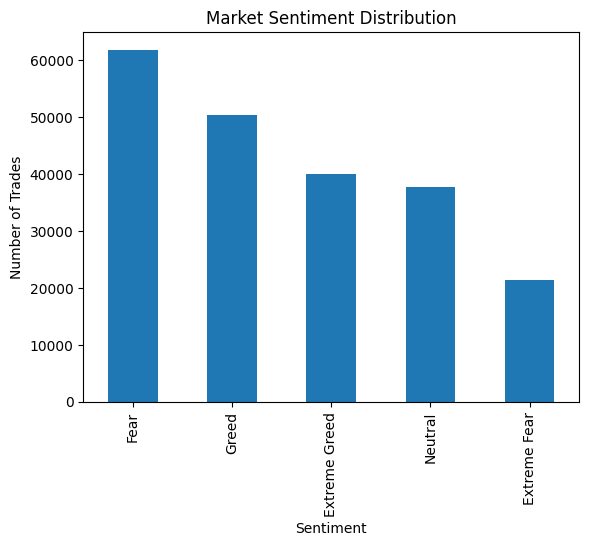

In [73]:
merged_df["classification"].value_counts().plot(
    kind="bar"
)

plt.title("Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.show()


1. `Fear` is the most dominant market sentiment in the dataset, indicating that trading activity occurred more frequently during cautious or pessimistic market conditions.
2. `Greed` and `Extreme Greed` also account for a significant portion of trading activity, showing that traders remained actively engaged during bullish market periods as well.
3. `Extreme Fear` has the lowest number of trades among all sentiment categories, suggesting that highly panic-driven market conditions occurred less frequently.
4. The overall distribution shows that the dataset contains substantial representation from all major sentiment states, making sentiment-based behavioral analysis statistically meaningful.
5. The higher concentration of trades during Fear conditions may indicate that volatile or uncertain market environments encourage increased trader participation and market activity.

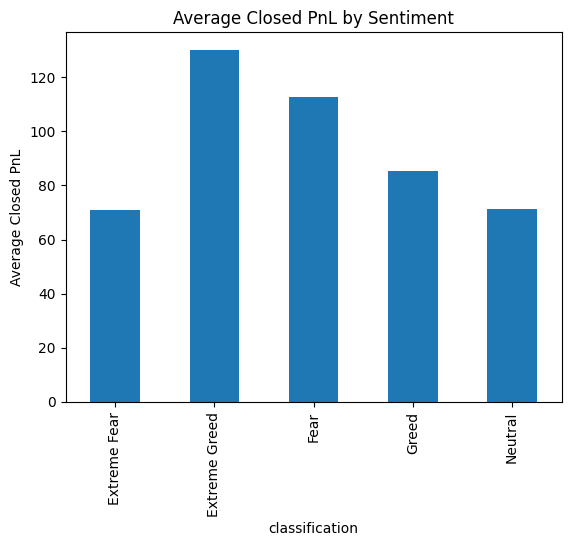

In [74]:
closed_trades.groupby("classification")["Closed PnL"].mean().plot(
    kind="bar"
)

plt.title("Average Closed PnL by Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

1. `Extreme Greed` exhibits the highest average realized profit (`Closed PnL`) among all sentiment categories, suggesting that traders tend to achieve stronger profitability during highly bullish market conditions.
2. `Fear` also shows relatively high average profitability, indicating that volatile or fearful markets may create profitable trading opportunities through dip-buying, short-selling, or rapid price movements.
3. `Greed`, `Neutral`, and `Extreme Fear` show comparatively lower average profitability, suggesting weaker trading opportunities or lower market momentum during those conditions.
4. The results imply that emotionally extreme market environments, especially strong bullish periods, may provide better profit-generating opportunities compared to stable or neutral market conditions.
5. Overall, the analysis suggests that market sentiment has a noticeable impact on realized trader profitability and trading outcomes.

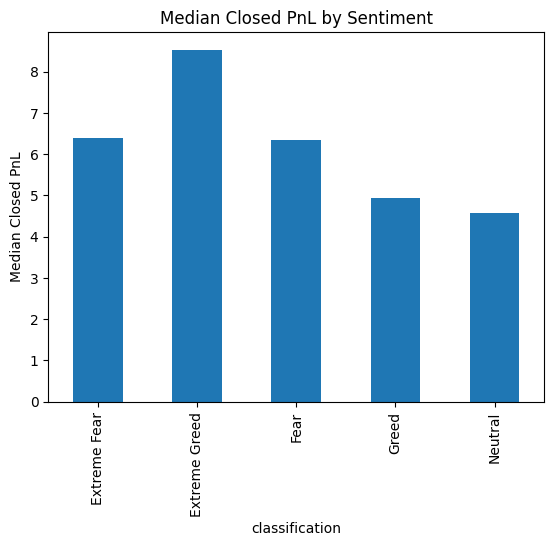

In [75]:
closed_trades.groupby("classification")["Closed PnL"].median().plot(
    kind="bar"
)

plt.title("Median Closed PnL by Sentiment")
plt.ylabel("Median Closed PnL")
plt.show()

1. `Extreme Greed` shows the highest median realized profit among all sentiment categories, indicating that not only large traders but also typical traders tend to perform better during strongly bullish market conditions.
2. `Fear` and `Extreme Fear` also exhibit relatively strong median profitability, suggesting that volatile and emotionally driven markets may create profitable trading opportunities for many participants.
3. `Neutral` market conditions display the lowest median profitability, which may reflect lower volatility and weaker trading momentum.
4. Compared to average profitability analysis, median values provide a more stable representation of typical trader performance by reducing the impact of extreme outlier trades.
5. Overall, the results suggest that emotionally extreme market conditions tend to produce stronger and more consistent trading profitability than stable market environments.

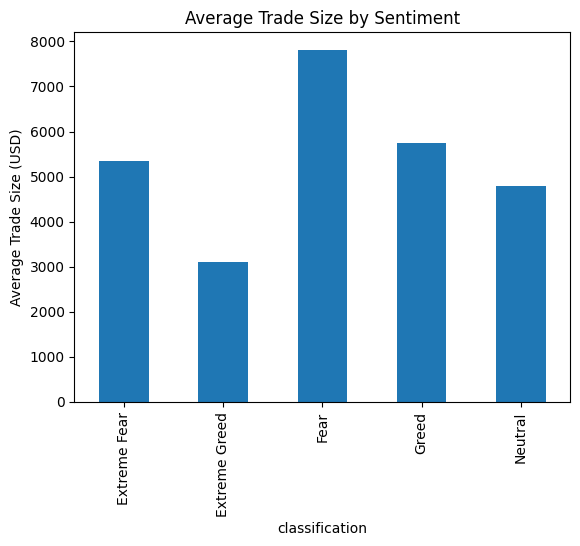

In [76]:
merged_df.groupby("classification")["Size USD"].mean().plot(
    kind="bar"
)

plt.title("Average Trade Size by Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.show()

1. `Fear` market conditions show the highest average trade size, indicating that traders tend to deploy larger amounts of capital during fearful or highly volatile market environments.
2. `Greed` and `Extreme Fear` also exhibit relatively high average trade sizes, suggesting increased market participation and aggressive positioning during emotionally intense periods.
3. `Extreme Greed` shows the lowest average trade size among all sentiment categories, which may indicate a larger number of smaller speculative trades rather than concentrated high-capital positions.
4. The results suggest that traders may take larger financial risks during uncertain or panic-driven market conditions, possibly due to dip-buying strategies, volatility trading, or short-selling opportunities.
5. Overall, the analysis indicates that market sentiment significantly influences trader risk exposure and capital deployment behavior.

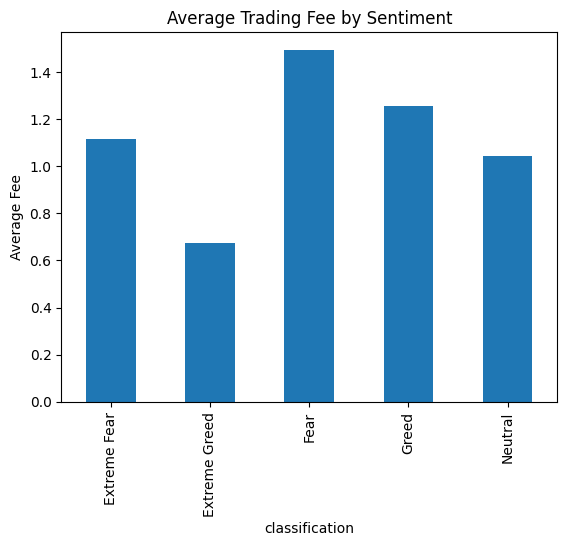

In [77]:
merged_df.groupby("classification")["Fee"].mean().plot(
    kind="bar"
)

plt.title("Average Trading Fee by Sentiment")
plt.ylabel("Average Fee")
plt.show()

1. `Fear` market conditions show the highest average trading fees, indicating increased trading intensity and larger capital deployment during fearful market periods.
2. `Greed` and `Extreme Fear` also exhibit relatively high average fees, suggesting active participation and aggressive trading behavior during emotionally volatile market conditions.
3. `Extreme Greed` shows the lowest average trading fees, which may indicate smaller average trade sizes or a larger number of low-capital speculative trades.
4. Since trading fees are generally correlated with trade volume and position size, the results support earlier observations that traders tend to take larger or more aggressive positions during fearful market conditions.
5. Overall, the analysis suggests that market sentiment significantly influences trading activity intensity, risk-taking behavior, and capital exposure in the market.

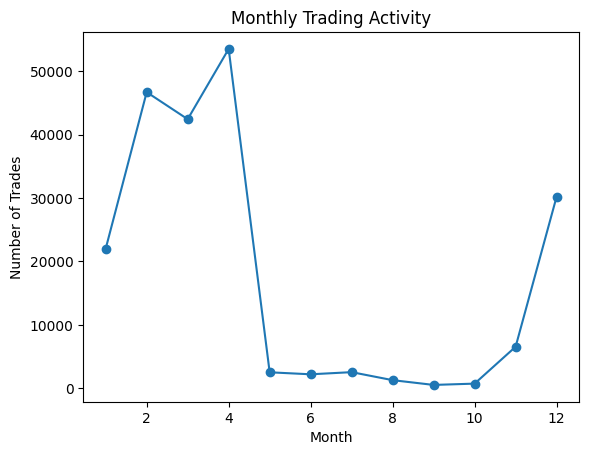

In [78]:
merged_df["month"].value_counts().sort_index().plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Trading Activity")
plt.xlabel("Month")
plt.ylabel("Number of Trades")
plt.show()

1. Trading activity is heavily concentrated during the early months of the year, particularly in February, March, and April, with April recording the highest number of trades.
2. After April, trading activity declines sharply and remains relatively low between May and October.
3. A noticeable recovery in trading activity occurs during November and December, indicating renewed market participation toward the end of the year.
4. The sharp fluctuations in monthly trade volume suggest that trader participation is strongly influenced by changing market conditions, volatility levels, and sentiment-driven market events.
5. Periods of high trading activity may correspond to phases of increased speculation, stronger price movement, or heightened market uncertainty.

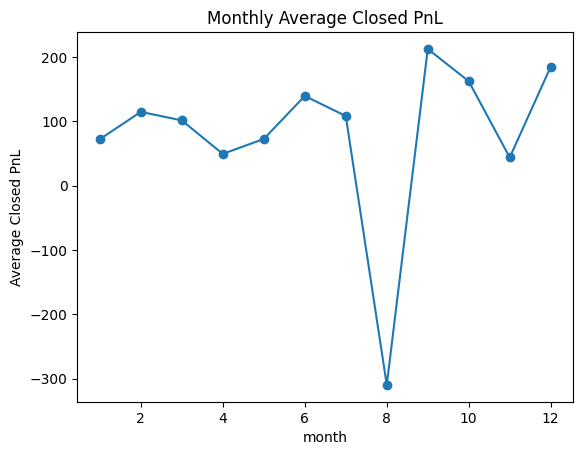

In [79]:
closed_trades.groupby("month")["Closed PnL"].mean().plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Average Closed PnL")
plt.ylabel("Average Closed PnL")
plt.show()

1. Average realized profitability varies significantly across different months, indicating changing market conditions and trading performance throughout the year.
2. August shows a sharp negative average Closed PnL, suggesting unfavorable trading conditions, increased losses, or possible high-volatility market disruptions during that period.
3. September, October, and December exhibit some of the highest average realized profits, indicating stronger trading opportunities and improved market performance during those months.
4. The large fluctuations in monthly profitability suggest that trader success is highly dependent on market regime, volatility, and prevailing market sentiment.
5. The presence of sudden spikes and drops in profitability also indicates the influence of outlier trades, leveraged positions, or whale-level trading activity within certain periods.

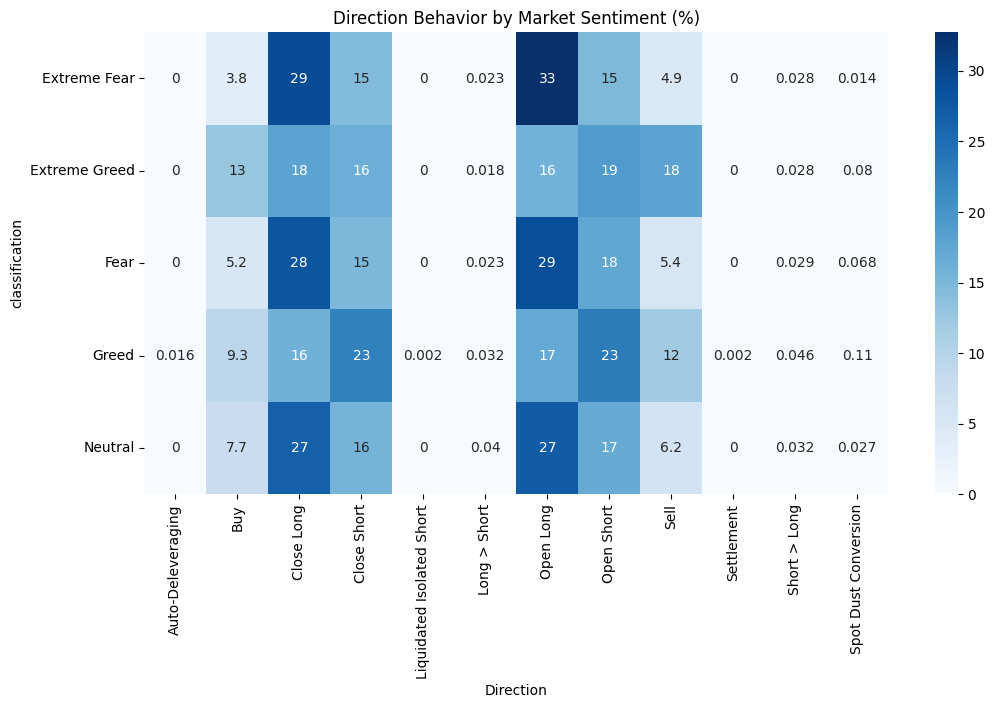

In [80]:
plt.figure(figsize=(12,6))

sns.heatmap(
    direction_percent,
    annot=True,
    cmap="Blues"
)

plt.title("Direction Behavior by Market Sentiment (%)")
plt.show()

1. `Fear` and `Extreme Fear` market conditions show the highest proportion of `Open Long` positions, indicating that traders actively open bullish positions during panic or declining market conditions.
2. The strong concentration of long-opening activity during fearful periods suggests the presence of dip-buying strategies and contrarian trading behavior.
3. `Greed` market conditions exhibit the highest proportion of `Open Short` and `Close Short` activity, suggesting that traders may anticipate market corrections or take profits during bullish phases.
4. `Extreme Greed` also shows increased BUY and SELL activity, indicating elevated speculative participation and higher market activity during euphoric conditions.
5. Long-closing activity remains consistently high across most sentiment categories, reflecting active position management and profit-taking behavior throughout varying market conditions.
6. Rare events such as liquidations, auto-deleveraging, and position reversals occur very infrequently and therefore have limited overall impact on trading behavior patterns.
7. Overall, the heatmap demonstrates that trader positioning behavior changes significantly across sentiment conditions, highlighting the strong influence of market psychology on trading decisions.

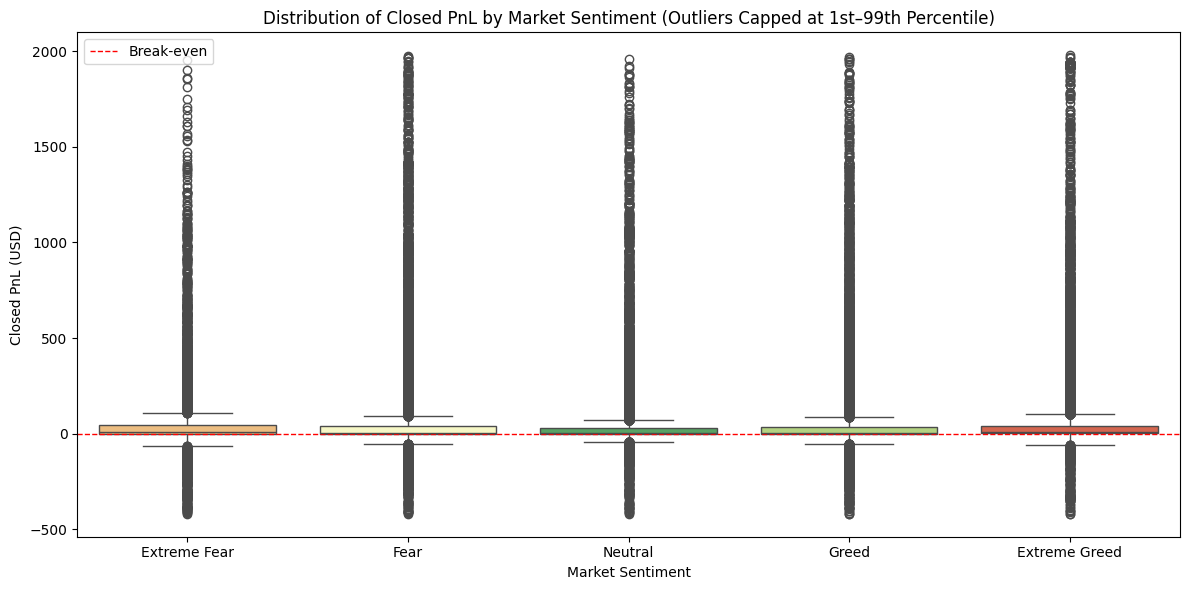

In [81]:
pnl_cap = closed_trades["Closed PnL"].quantile(0.99)
pnl_floor = closed_trades["Closed PnL"].quantile(0.01)
plot_data = closed_trades[
    (closed_trades["Closed PnL"] <= pnl_cap) & 
    (closed_trades["Closed PnL"] >= pnl_floor)
]

sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_data,
    x="classification",
    y="Closed PnL",
    hue="classification",
    order=sentiment_order,
    palette="RdYlGn",
    legend=False
)
plt.title("Distribution of Closed PnL by Market Sentiment (Outliers Capped at 1st–99th Percentile)")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL (USD)")
plt.axhline(0, color="red", linestyle="--", linewidth=1, label="Break-even")
plt.legend()
plt.tight_layout()
plt.show()

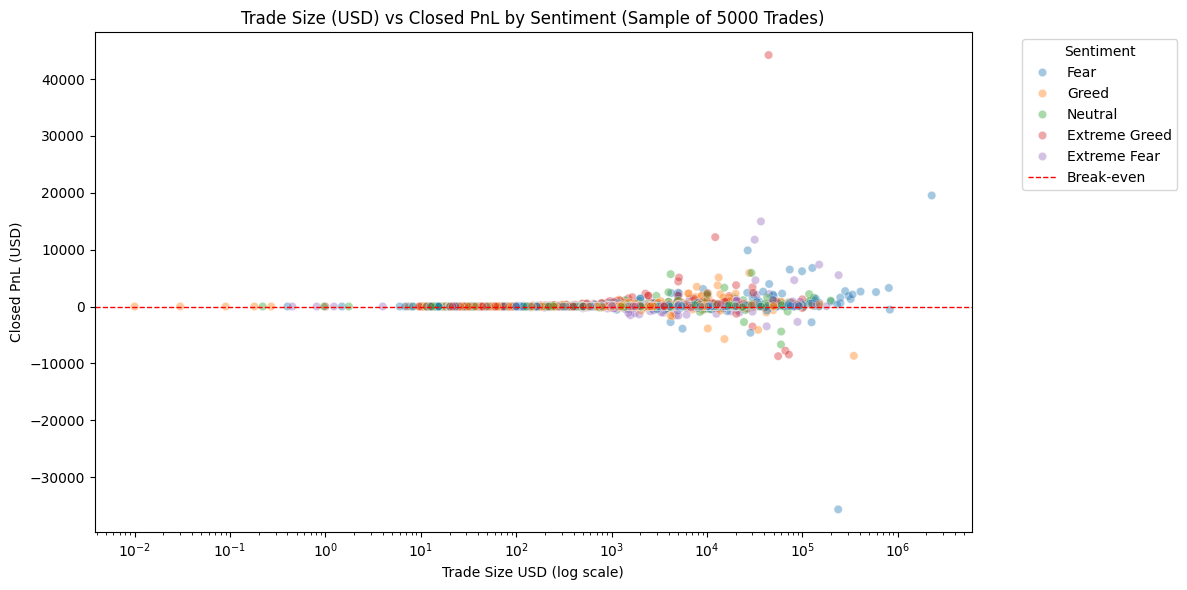

In [82]:
sample = closed_trades.sample(5000, random_state=42)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=sample,
    x="Size USD",
    y="Closed PnL",
    hue="classification",
    alpha=0.4,
    palette="tab10"
)
plt.xscale("log")
plt.title("Trade Size (USD) vs Closed PnL by Sentiment (Sample of 5000 Trades)")
plt.xlabel("Trade Size USD (log scale)")
plt.ylabel("Closed PnL (USD)")
plt.axhline(0, color="red", linestyle="--", linewidth=1, label="Break-even")
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

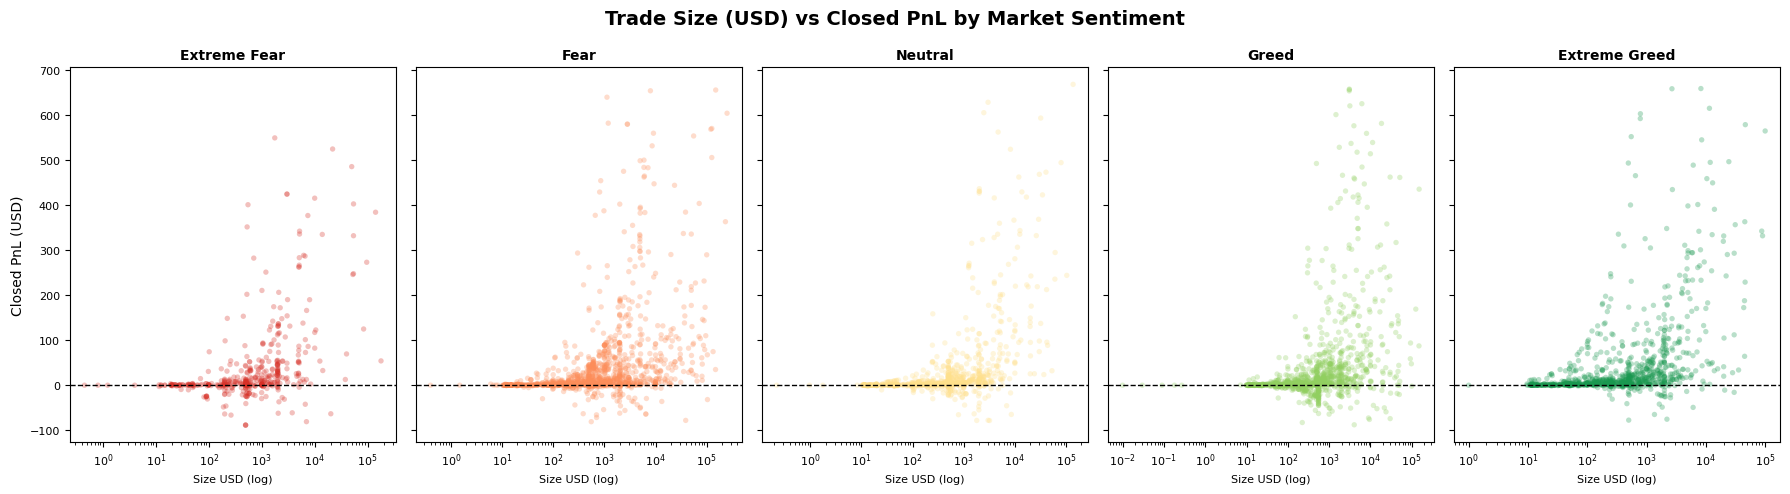

In [83]:
sample = closed_trades.sample(5000, random_state=42)

# Cap PnL for visual clarity
pnl_cap = sample["Closed PnL"].quantile(0.97)
pnl_floor = sample["Closed PnL"].quantile(0.03)
sample_plot = sample[
    (sample["Closed PnL"] <= pnl_cap) &
    (sample["Closed PnL"] >= pnl_floor)
]

sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
palette = ["#d73027", "#fc8d59", "#fee08b", "#91cf60", "#1a9850"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True)
fig.suptitle("Trade Size (USD) vs Closed PnL by Market Sentiment", fontsize=14, fontweight="bold")

for ax, sentiment, color in zip(axes, sentiment_order, palette):
    subset = sample_plot[sample_plot["classification"] == sentiment]
    ax.scatter(
        subset["Size USD"],
        subset["Closed PnL"],
        alpha=0.3,
        color=color,
        edgecolors="none",
        s=15
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_title(sentiment, fontsize=10, fontweight="bold")
    ax.set_xlabel("Size USD (log)", fontsize=8)
    ax.tick_params(axis="both", labelsize=8)

axes[0].set_ylabel("Closed PnL (USD)", fontsize=10)
plt.tight_layout()
plt.show()

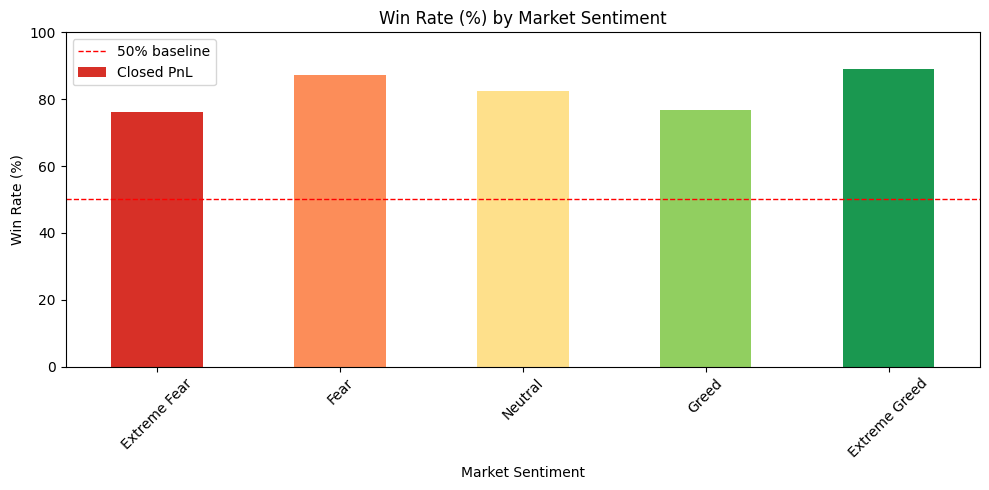

In [84]:
win_rate = (closed_trades["Closed PnL"] > 0).groupby(
    closed_trades["classification"]
).mean() * 100

win_rate = win_rate.reindex(sentiment_order)

plt.figure(figsize=(10, 5))
win_rate.plot(kind="bar", color=["#d73027","#fc8d59","#fee08b","#91cf60","#1a9850"])
plt.title("Win Rate (%) by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.ylim(0, 100)
plt.axhline(50, color="red", linestyle="--", linewidth=1, label="50% baseline")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1. The box plot reveals that `Extreme Greed` and `Fear` conditions produce the widest PnL spread, confirming higher profit potential but also higher risk during emotionally extreme markets.
2. The median PnL line sits above zero across all sentiment categories, indicating that the typical trader is profitable regardless of market condition.
3. The scatter plot shows that larger trade sizes do not always guarantee larger profits — high-size trades appear on both sides of the break-even line, highlighting the importance of timing and direction over size alone.
4. The win rate chart confirms that `Extreme Greed` leads with ~89% win rate while `Extreme Fear` and `Greed` sit lowest at ~76%, suggesting that market momentum clarity (not just volatility) drives consistent winning behavior.
5. All sentiment categories show win rates well above 50%, indicating that traders in this dataset are generally skilled or have systematic strategies rather than random trading behavior.

### SUMMARY

1. Market sentiment significantly influences trader behavior, profitability, trade size, and position management patterns across all sentiment categories.

2. Extreme Greed market conditions exhibit the highest average, median, and win rate profitability (~89%), suggesting bullish momentum environments create the strongest trading opportunities.

3. Fear and Extreme Fear periods show larger average trade sizes and higher trading fees, indicating aggressive capital deployment during volatile conditions.

4. Direction analysis reveals traders open more long positions during Fear and Extreme Fear, confirming strong dip-buying and contrarian behavior. Greed conditions show increased short activity, indicating traders anticipate corrections during euphoric phases.

5. Win rate analysis shows all sentiment categories exceed 75%, with Extreme Greed leading at ~89% and Extreme Fear lowest at ~76%.

6. Kruskal-Wallis testing statistically confirms that PnL and trade size differences across sentiment groups are not due to chance (p≈0.000). Notably, Greed and Neutral conditions are not significantly different from each other in PnL outcomes.

7. Drawdown analysis reveals a counterintuitive finding — Greed conditions carry the highest tail risk with worst single-day loss of -$358,963, while Extreme Fear shows the most contained downside (-$77,308). Fear days offer the best risk-reward combination.

8. Trade frequency analysis shows Extreme Fear triggers the highest daily trading activity (avg 1,528 trades/day), while Greed and Extreme Greed show the lowest (260–350 trades/day), indicating panic drives activity more than euphoria.

9. Trader segmentation across 32 unique accounts reveals three distinct behavioral archetypes — frequent high-activity traders, net winners vs losers, and small high-frequency vs large high-capital traders — each profitable through different strategies.

10. Profitability distributions are highly skewed with a small number of whale trades dominating overall results. Speculative assets like DOGE, SOL, AVAX, and ENA show stronger realized profitability especially during Fear conditions.

11. Monthly analysis reveals April had peak trading activity while August showed the worst average profitability, confirming strong regime-dependent performance variation.

# Conclusion

This analysis provides a comprehensive examination of the relationship between Bitcoin 
market sentiment and trader behavior using over 211,000 trades from Hyperliquid combined 
with the Fear & Greed Index across 32 unique trader accounts.

Several clear and statistically validated patterns emerged:

**Profitability is sentiment-driven.** Extreme Greed conditions produced the highest 
average, median, and win rate (~89%) across all sentiment categories. Fear conditions 
were a close second, suggesting that both ends of the emotional spectrum — panic and 
euphoria — create stronger trading opportunities than neutral or moderate conditions.

**Risk appetite scales with fear.** Traders deployed significantly larger capital and 
paid higher fees during Fear and Extreme Fear periods, pointing to aggressive dip-buying 
and contrarian positioning behavior. Trade size differences across sentiment groups were 
statistically confirmed with H=1945 (p≈0.000).

**Positioning behavior is sentiment-aware.** Long positions dominated during Fear and 
Extreme Fear, while short activity increased during Greed, indicating traders actively 
adjust directional bias based on market psychology.

**Drawdown risk is highest during Greed — not Fear.** The worst single-day loss of 
-$358,963 occurred during Greed conditions, more than 2.5x worse than any other 
sentiment category. Fear days paradoxically offer both the highest average daily PnL 
($5,328) and more contained downside risk — making Fear the best risk-reward regime.

**Trade frequency is driven by panic.** Extreme Fear triggers nearly 4x more daily 
trades than Greed conditions, confirming that uncertainty and volatility — not 
confidence — drive the most intense market participation.

**Trader archetypes are distinct.** Segmentation of 32 accounts revealed that 90.6% 
are net winners overall. Small traders win more frequently (44% win rate) while large 
traders generate higher absolute PnL through bigger position sizes. Frequent traders 
outperform infrequent ones in both total PnL and win rate.

**Results are statistically robust.** Kruskal-Wallis and pairwise Mann-Whitney U tests 
confirmed PnL differences across sentiment groups are real and significant (H=730, 
p≈0.000), with Greed and Neutral being the only pair not significantly different.

Overall, market sentiment is not merely a psychological indicator — it is a measurable 
and statistically validated driver of trader behavior, capital deployment, drawdown risk, 
and profitability in cryptocurrency markets.

# Strategic Insights and Recommendations

**1. Use Fear days as primary entry opportunities**
Fear conditions consistently deliver the best risk-reward combination — highest average 
daily PnL ($5,328), high win rate (~87%), and the second lowest drawdown risk. Traders 
should increase position sizes and entry frequency during Fear rather than retreating, 
contrary to typical retail behavior.

**2. Treat Extreme Greed as a profitability window but monitor tail risk**
Traders achieved their highest win rates (~89%) and strongest median PnL during Extreme 
Greed. However, Greed conditions also produced the largest single-day losses (-$358,963). 
Strategy: ride momentum during Extreme Greed but implement strict daily loss limits to 
protect against sudden tail-risk events.

**3. Avoid over-trading during Greed and Neutral conditions**
These two sentiment states are statistically indistinguishable in PnL outcomes and show 
the lowest win rates (~76%). Reduce position frequency and size during these periods — 
the data suggests flat or unclear market momentum creates unfavorable trading conditions.

**4. Adopt a small-trader high-frequency approach for consistent wins**
Small traders in this dataset win more frequently (44% win rate) by trading more often 
(avg 9,015 trades). This high-frequency, lower-capital approach outperforms on 
consistency. For traders with limited capital, frequent smaller trades during high-
sentiment-clarity days (Extreme Fear or Extreme Greed) is the optimal strategy.

**5. Focus on high-volatility assets during Fear conditions**
Assets like ENA, DOGE, SOL, AVAX, and ARB showed the strongest profitability during 
Fear-driven markets. Maintain a sentiment-filtered watchlist — activate high-volatility 
speculative coins during Fear and rotate to momentum assets during Extreme Greed.

**6. Never rely on mean PnL alone for strategy evaluation**
Given extreme skewness in PnL distributions (skewness > 20), average returns are 
heavily distorted by whale outliers. Always evaluate strategies using median PnL, 
win rate, and drawdown proxy together for an accurate picture of typical performance.

# Future Improvements

Future analysis could include:
- Leverage data enrichment for risk-adjusted performance analysis
- Trader clustering and profiling by account-level behavior
- Machine learning models for profitability prediction based on sentiment
- Anomaly detection for whale trades and outlier activity
- Sentiment-based predictive trading signal systems
- Coin-specific volatility and momentum analysis
- Time-series modeling of sentiment shifts and their lagged effect on trader behavior